# 07 — Evaluación incremental de parámetros ECG

Este notebook consolida las métricas generadas en `06_modelado_predictivo.ipynb` y evalúa el aporte incremental de las modalidades de información definidas en el TFM.

El foco principal es la comparación entre el escenario clínico basal y el escenario clínico enriquecido con parámetros electrocardiográficos estructurados:

```text
E1_CLINICO → E3_CLINICO_ECG
```

Como análisis complementario, se evalúa si el aporte ECG se mantiene cuando el escenario base ya incorpora antecedentes clínicos derivados mediante NLP:

```text
E2_CLINICO_NLP → E4_CLINICO_NLP_ECG
```

Este notebook no entrena modelos. Su función es comparar resultados ya obtenidos, generar tablas de diferencias absolutas y relativas, construir rankings de modelos y exportar artefactos de evaluación incremental.

## 1. Entradas y salidas

### Entradas esperadas

```text
Metricas_Modelado_TFM.xlsx
Metricas_Modelado_Subsets_TFM.xlsx
Predicciones_Modelos_TFM.xlsx
Variables_Modelado_TFM.xlsx
```

### Salidas generadas

```text
Comparacion_Incremental_ECG_TFM.xlsx
Ranking_Modelos_Escenarios_TFM.xlsx
Resumen_Evaluacion_Incremental_TFM.txt
figuras_evaluacion_incremental/metricas_por_escenario_modelo.png
figuras_evaluacion_incremental/delta_incremental_ecg.png
figuras_evaluacion_incremental/ranking_auprc_por_escenario.png
```

`Metricas_Modelado_Subsets_TFM.xlsx` se utiliza de forma explícita para calcular la evaluación incremental por `SUBSET_BATERIA`.


In [2]:
# Instalación de dependencias requeridas
import importlib.util
import subprocess
import sys

DEPENDENCIAS = {
    "pandas": "pandas",
    "numpy": "numpy",
    "openpyxl": "openpyxl",
    "xlsxwriter": "XlsxWriter",
    "matplotlib": "matplotlib",
}

for modulo, paquete in DEPENDENCIAS.items():
    if importlib.util.find_spec(modulo) is None:
        print(f"Instalando dependencia faltante: {paquete}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", paquete])
    else:
        print(f"Dependencia disponible: {modulo}")

Dependencia disponible: pandas
Dependencia disponible: numpy
Dependencia disponible: openpyxl
Dependencia disponible: xlsxwriter
Dependencia disponible: matplotlib


In [4]:
# Carga de librerías
from pathlib import Path
from datetime import datetime
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

RANDOM_STATE = 42
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    f1_score,
)


## 2. Configuración de rutas

Por defecto, el notebook usa como directorio base la carpeta local donde se ejecuta. Si los archivos se encuentran en otra ubicación, modificar `BASE_DIR`.

In [5]:
# Configuración de rutas
BASE_DIR = Path.cwd()
OUT_DIR = BASE_DIR
FIG_DIR = OUT_DIR / "figuras_evaluacion_incremental"
FIG_DIR.mkdir(parents=True, exist_ok=True)

PATH_METRICAS = BASE_DIR / "Metricas_Modelado_TFM.xlsx"
PATH_METRICAS_SUBSETS = BASE_DIR / "Metricas_Modelado_Subsets_TFM.xlsx"
PATH_PREDICCIONES = BASE_DIR / "Predicciones_Modelos_TFM.xlsx"
PATH_VARIABLES = BASE_DIR / "Variables_Modelado_TFM.xlsx"

OUT_COMPARACION = OUT_DIR / "Comparacion_Incremental_ECG_TFM.xlsx"
OUT_RANKING = OUT_DIR / "Ranking_Modelos_Escenarios_TFM.xlsx"
OUT_REPORTE = OUT_DIR / "Resumen_Evaluacion_Incremental_TFM.txt"

FIG_METRICAS = FIG_DIR / "metricas_por_escenario_modelo.png"
FIG_DELTA_ECG = FIG_DIR / "delta_incremental_ecg.png"
FIG_RANKING = FIG_DIR / "ranking_auprc_por_escenario.png"

print("BASE_DIR:", BASE_DIR)
print("FIG_DIR:", FIG_DIR)
print("PATH_METRICAS:", PATH_METRICAS)
print("PATH_METRICAS_SUBSETS:", PATH_METRICAS_SUBSETS)


BASE_DIR: e:\Capacitacion 2025\Magister en Inteligencia Artificial\99 Trabajo Fin de Estudios TFE\GitHub\tfm-ecg-riesgo-cardiometabolico\notebooks
FIG_DIR: e:\Capacitacion 2025\Magister en Inteligencia Artificial\99 Trabajo Fin de Estudios TFE\GitHub\tfm-ecg-riesgo-cardiometabolico\notebooks\figuras_evaluacion_incremental
PATH_METRICAS: e:\Capacitacion 2025\Magister en Inteligencia Artificial\99 Trabajo Fin de Estudios TFE\GitHub\tfm-ecg-riesgo-cardiometabolico\notebooks\Metricas_Modelado_TFM.xlsx
PATH_METRICAS_SUBSETS: e:\Capacitacion 2025\Magister en Inteligencia Artificial\99 Trabajo Fin de Estudios TFE\GitHub\tfm-ecg-riesgo-cardiometabolico\notebooks\Metricas_Modelado_Subsets_TFM.xlsx


## 3. Funciones auxiliares

In [6]:
def require_file(path: Path):
    if not path.exists():
        raise FileNotFoundError(f"No se encontró el archivo requerido: {path}")


def normalize_colname(c):
    return str(c).strip().replace(" ", "_").replace("-", "_")


def normalize_metric_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [normalize_colname(c) for c in df.columns]

    rename_map = {
        "Scenario": "escenario",
        "Escenario": "escenario",
        "SCENARIO": "escenario",
        "Modelo": "modelo",
        "MODEL": "modelo",
        "model": "modelo",
        "F1_Score": "F1",
        "F1_SCORE": "F1",
        "f1": "F1",
        "roc_auc": "ROC_AUC",
        "ROC_AUC_SCORE": "ROC_AUC",
        "roc_auc_score": "ROC_AUC",
        "pr_auc": "AUPRC",
        "PR_AUC": "AUPRC",
        "average_precision": "AUPRC",
        "Average_Precision": "AUPRC",
        "n_features_usadas": "n_features",
        "n_variables": "n_features",
        "n": "n_registros",
    }
    df = df.rename(columns={c: rename_map.get(c, c) for c in df.columns})

    required = ["escenario", "modelo"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Faltan columnas obligatorias en métricas: {missing}")

    for c in ["Accuracy", "Precision", "Recall", "F1", "ROC_AUC", "AUPRC"]:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

    return df


def read_excel_first_sheet(path: Path) -> pd.DataFrame:
    require_file(path)
    xls = pd.ExcelFile(path)
    return pd.read_excel(path, sheet_name=xls.sheet_names[0])




def read_excel_sheet(path: Path, preferred_sheet: str | None = None) -> pd.DataFrame:
    """Lee una hoja específica si existe; en caso contrario, lee la primera hoja."""
    require_file(path)
    xls = pd.ExcelFile(path)
    sheet = preferred_sheet if preferred_sheet in xls.sheet_names else xls.sheet_names[0]
    return pd.read_excel(path, sheet_name=sheet)


def standardize_subset_column(df: pd.DataFrame) -> tuple[pd.DataFrame, str | None]:
    """Estandariza la columna de subconjunto estructural a SUBSET_BATERIA."""
    df = df.copy()
    candidates = [
        "SUBSET_BATERIA", "BATERIA", "BATERIA_ESTRUCTURAL", "SUBSET_EXAMENES",
        "bateria", "subset", "Subset", "Bateria", "CLUSTER_BATERIA", "BATERIA_CLUSTER"
    ]
    detected = next((c for c in candidates if c in df.columns), None)
    if detected and detected != "SUBSET_BATERIA":
        df = df.rename(columns={detected: "SUBSET_BATERIA"})
        detected = "SUBSET_BATERIA"
    return df, detected


def safe_rel_delta(final, base):
    if pd.isna(final) or pd.isna(base) or base == 0:
        return np.nan
    return (final - base) / base


def scenario_label(s):
    labels = {
        "E1_CLINICO": "E1 Clínico",
        "E2_CLINICO_NLP": "E2 Clínico + NLP",
        "E3_CLINICO_ECG": "E3 Clínico + ECG",
        "E4_CLINICO_NLP_ECG": "E4 Clínico + NLP + ECG",
    }
    return labels.get(str(s), str(s))

# Normalización canónica de nombres de modelos y escenarios
# Esta función elimina incongruencias entre nombres internos exportados por el notebook 06
# y nombres formales utilizados en el TFM y en la evaluación incremental.
MODELO_CANONICO_MAP = {
    "LogisticRegression": "Logistic Regression",
    "Logistic_Regression": "Logistic Regression",
    "logistic_regression": "Logistic Regression",
    "Logistic Regression": "Logistic Regression",
    "RandomForest": "Random Forest",
    "Random_Forest": "Random Forest",
    "random_forest": "Random Forest",
    "Random Forest": "Random Forest",
    "XGBoost": "XGBoost",
    "XGBClassifier": "XGBoost",
    "xgboost": "XGBoost",
    "LightGBM": "LightGBM",
    "LGBMClassifier": "LightGBM",
    "lightgbm": "LightGBM",
}

ESCENARIO_CANONICO_MAP = {
    "E1_CLINICO": "E1_CLINICO",
    "E1_CLÍNICO": "E1_CLINICO",
    "E1_CLINICO_BASE": "E1_CLINICO",
    "E1": "E1_CLINICO",
    "E2_CLINICO_NLP": "E2_CLINICO_NLP",
    "E2_CLÍNICO_NLP": "E2_CLINICO_NLP",
    "E2": "E2_CLINICO_NLP",
    "E3_CLINICO_ECG": "E3_CLINICO_ECG",
    "E3_CLÍNICO_ECG": "E3_CLINICO_ECG",
    "E3": "E3_CLINICO_ECG",
    "E4_CLINICO_NLP_ECG": "E4_CLINICO_NLP_ECG",
    "E4_CLÍNICO_NLP_ECG": "E4_CLINICO_NLP_ECG",
    "E4": "E4_CLINICO_NLP_ECG",
}


def canonicalize_model_name(value):
    if pd.isna(value):
        return value
    s = str(value).strip()
    s = MODELO_CANONICO_MAP.get(s, s)
    return s


def canonicalize_scenario_name(value):
    if pd.isna(value):
        return value
    s = str(value).strip()
    s = s.replace(" ", "_").replace("-", "_").upper()
    s = ESCENARIO_CANONICO_MAP.get(s, s)
    return s


def canonicalize_evaluation_table(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    if "modelo" in df.columns:
        df["modelo"] = df["modelo"].apply(canonicalize_model_name)
    if "escenario" in df.columns:
        df["escenario"] = df["escenario"].apply(canonicalize_scenario_name)
    return df


def validate_model_name_consistency(df: pd.DataFrame, expected_models):
    modelos_presentes = sorted(df["modelo"].dropna().astype(str).unique().tolist())
    modelos_no_canonicos = [m for m in modelos_presentes if m not in expected_models]
    if modelos_no_canonicos:
        raise ValueError(
            "Se detectaron nombres de modelos no canónicos luego de la normalización: "
            f"{modelos_no_canonicos}. Revisar MODELO_CANONICO_MAP."
        )
    return modelos_presentes


## 4. Carga de métricas del modelado predictivo

In [7]:
# Carga de métricas globales y métricas por subconjunto estructural
metricas = read_excel_sheet(PATH_METRICAS, preferred_sheet="METRICAS")
metricas = normalize_metric_columns(metricas)
metricas = canonicalize_evaluation_table(metricas)

metricas_subsets = read_excel_sheet(PATH_METRICAS_SUBSETS, preferred_sheet="METRICAS_POR_BATERIA")
metricas_subsets = normalize_metric_columns(metricas_subsets)
metricas_subsets = canonicalize_evaluation_table(metricas_subsets)
metricas_subsets, subset_col_subsets = standardize_subset_column(metricas_subsets)

if subset_col_subsets is None:
    raise ValueError(
        "Metricas_Modelado_Subsets_TFM.xlsx no contiene una columna compatible con SUBSET_BATERIA/BATERIA. "
        "Revisar la exportación del notebook 06."
    )

# Cargas auxiliares opcionales
predicciones = None
variables_modelado = None
if PATH_PREDICCIONES.exists():
    predicciones = read_excel_first_sheet(PATH_PREDICCIONES)
if PATH_VARIABLES.exists():
    variables_modelado = read_excel_first_sheet(PATH_VARIABLES)

# Normalización canónica de tablas auxiliares, cuando contienen columnas compatibles
if predicciones is not None:
    predicciones.columns = [normalize_colname(c) for c in predicciones.columns]
    predicciones = canonicalize_evaluation_table(predicciones)
if variables_modelado is not None:
    variables_modelado.columns = [normalize_colname(c) for c in variables_modelado.columns]
    variables_modelado = canonicalize_evaluation_table(variables_modelado)

print("Nombres de modelos normalizados a nomenclatura formal del TFM.")
print("Métricas globales cargadas:", metricas.shape)
print("Métricas por SUBSET_BATERIA cargadas:", metricas_subsets.shape)
print("Columna estructural estandarizada: SUBSET_BATERIA")

display(metricas.head())
display(metricas_subsets.head())


Nombres de modelos normalizados a nomenclatura formal del TFM.
Métricas globales cargadas: (16, 24)
Métricas por SUBSET_BATERIA cargadas: (64, 17)
Columna estructural estandarizada: SUBSET_BATERIA


,escenario,modelo,modelo_key,estado,error,n_total,n_train,n_test,features,numeric_features,categorical_features,columna_bateria,prevalencia_train,prevalencia_test,Accuracy,Precision,Recall,F1,ROC_AUC,AUPRC,TN,FP,FN,TP
0,E1_CLINICO,Logistic Regression,LogisticRegression,OK,NaN,3779,3023,756,22,20,2,SUBSET_BATERIA,0.116441,0.116402,0.879630,0.490683,0.897727,0.634538,0.930917,0.713767,586,82,9,79
1,E1_CLINICO,Random Forest,RandomForest,OK,NaN,3779,3023,756,22,20,2,SUBSET_BATERIA,0.116441,0.116402,0.966931,0.956522,0.750000,0.840764,0.993723,0.961742,665,3,22,66
2,E1_CLINICO,XGBoost,XGBoost,OK,NaN,3779,3023,756,22,20,2,SUBSET_BATERIA,0.116441,0.116402,0.984127,0.952381,0.909091,0.930233,0.996734,0.980383,664,4,8,80
3,E1_CLINICO,LightGBM,LightGBM,OK,NaN,3779,3023,756,22,20,2,SUBSET_BATERIA,0.116441,0.116402,0.981481,0.930233,0.909091,0.919540,0.995016,0.972917,662,6,8,80
4,E2_CLINICO_NLP,Logistic Regression,LogisticRegression,OK,NaN,3779,3023,756,34,32,2,SUBSET_BATERIA,0.116441,0.116402,0.880952,0.493750,0.897727,0.637097,0.930780,0.705131,587,81,9,79


,escenario,modelo,columna_bateria,SUBSET_BATERIA,n_test_bateria,n_positivos_bateria,n_negativos_bateria,Accuracy,Precision,Recall,F1,ROC_AUC,AUPRC,TN,FP,FN,TP
0,E1_CLINICO,Logistic Regression,SUBSET_BATERIA,BATERIA_A,175,56,119,0.800000,0.640000,0.857143,0.732824,0.869148,0.750984,92,27,8,48
1,E1_CLINICO,Logistic Regression,SUBSET_BATERIA,BATERIA_B,249,19,230,0.839357,0.315789,0.947368,0.473684,0.970709,0.720516,191,39,1,18
2,E1_CLINICO,Logistic Regression,SUBSET_BATERIA,BATERIA_C,154,12,142,0.896104,0.428571,1.000000,0.600000,0.970070,0.709289,126,16,0,12
3,E1_CLINICO,Logistic Regression,SUBSET_BATERIA,BATERIA_D,178,1,177,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,177,0,0,1
4,E1_CLINICO,Random Forest,SUBSET_BATERIA,BATERIA_A,175,56,119,0.902857,0.953488,0.732143,0.828283,0.980867,0.961944,117,2,15,41


## 5. Validación de escenarios, modelos y métricas

In [8]:
ESCENARIOS_ESPERADOS = [
    "E1_CLINICO",
    "E2_CLINICO_NLP",
    "E3_CLINICO_ECG",
    "E4_CLINICO_NLP_ECG",
]

MODELOS_ESPERADOS = [
    "Logistic Regression",
    "Random Forest",
    "XGBoost",
    "LightGBM",
]

METRICAS_EVALUACION = ["Accuracy", "Precision", "Recall", "F1", "ROC_AUC", "AUPRC"]

escenarios_presentes = sorted(metricas["escenario"].dropna().astype(str).unique().tolist())
modelos_presentes = validate_model_name_consistency(metricas, MODELOS_ESPERADOS)
metricas_presentes = [m for m in METRICAS_EVALUACION if m in metricas.columns]

faltan_escenarios = [e for e in ESCENARIOS_ESPERADOS if e not in escenarios_presentes]
faltan_metricas = [m for m in METRICAS_EVALUACION if m not in metricas.columns]
faltan_modelos = [m for m in MODELOS_ESPERADOS if m not in modelos_presentes]

print("Escenarios presentes:", escenarios_presentes)
print("Modelos presentes:", modelos_presentes)
print("Métricas presentes:", metricas_presentes)

if faltan_escenarios:
    raise ValueError(f"Faltan escenarios requeridos para evaluación incremental: {faltan_escenarios}")
if faltan_metricas:
    raise ValueError(f"Faltan métricas requeridas: {faltan_metricas}")
if faltan_modelos:
    raise ValueError(
        "Faltan modelos requeridos para la comparación definida en el TFM: "
        f"{faltan_modelos}. Si el entrenamiento fue omitido por dependencia, revisar notebook 06."
    )

print("Validación de escenarios, modelos y métricas: OK")

Escenarios presentes: ['E1_CLINICO', 'E2_CLINICO_NLP', 'E3_CLINICO_ECG', 'E4_CLINICO_NLP_ECG']
Modelos presentes: ['LightGBM', 'Logistic Regression', 'Random Forest', 'XGBoost']
Métricas presentes: ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC', 'AUPRC']
Validación de escenarios, modelos y métricas: OK


## 6. Definición de comparaciones incrementales

In [9]:
COMPARACIONES = [
    {
        "comparacion": "E1_CLINICO_vs_E3_CLINICO_ECG",
        "escenario_base": "E1_CLINICO",
        "escenario_final": "E3_CLINICO_ECG",
        "modalidad_agregada": "ECG",
        "tipo": "principal_ecg_sobre_clinico",
    },
    {
        "comparacion": "E2_CLINICO_NLP_vs_E4_CLINICO_NLP_ECG",
        "escenario_base": "E2_CLINICO_NLP",
        "escenario_final": "E4_CLINICO_NLP_ECG",
        "modalidad_agregada": "ECG",
        "tipo": "complementaria_ecg_sobre_clinico_nlp",
    },
    {
        "comparacion": "E1_CLINICO_vs_E2_CLINICO_NLP",
        "escenario_base": "E1_CLINICO",
        "escenario_final": "E2_CLINICO_NLP",
        "modalidad_agregada": "NLP",
        "tipo": "auxiliar_nlp_sobre_clinico",
    },
    {
        "comparacion": "E1_CLINICO_vs_E4_CLINICO_NLP_ECG",
        "escenario_base": "E1_CLINICO",
        "escenario_final": "E4_CLINICO_NLP_ECG",
        "modalidad_agregada": "NLP+ECG",
        "tipo": "auxiliar_multimodal_completo",
    },
    {
        "comparacion": "E3_CLINICO_ECG_vs_E4_CLINICO_NLP_ECG",
        "escenario_base": "E3_CLINICO_ECG",
        "escenario_final": "E4_CLINICO_NLP_ECG",
        "modalidad_agregada": "NLP",
        "tipo": "auxiliar_nlp_sobre_clinico_ecg",
    },
]

pd.DataFrame(COMPARACIONES)

,comparacion,escenario_base,escenario_final,modalidad_agregada,tipo
0,E1_CLINICO_vs_E3_CLINICO_ECG,E1_CLINICO,E3_CLINICO_ECG,ECG,principal_ecg_sobre_clinico
1,E2_CLINICO_NLP_vs_E4_CLINICO_NLP_ECG,E2_CLINICO_NLP,E4_CLINICO_NLP_ECG,ECG,complementaria_ecg_sobre_clinico_nlp
2,E1_CLINICO_vs_E2_CLINICO_NLP,E1_CLINICO,E2_CLINICO_NLP,NLP,auxiliar_nlp_sobre_clinico
3,E1_CLINICO_vs_E4_CLINICO_NLP_ECG,E1_CLINICO,E4_CLINICO_NLP_ECG,NLP+ECG,auxiliar_multimodal_completo
4,E3_CLINICO_ECG_vs_E4_CLINICO_NLP_ECG,E3_CLINICO_ECG,E4_CLINICO_NLP_ECG,NLP,auxiliar_nlp_sobre_clinico_ecg


## 7. Cálculo de diferencias absolutas y relativas

Las diferencias se calculan por modelo, comparando el mismo algoritmo entre dos escenarios.

In [10]:
rows = []
for comp in COMPARACIONES:
    base_df = metricas[metricas["escenario"].astype(str) == comp["escenario_base"]].copy()
    final_df = metricas[metricas["escenario"].astype(str) == comp["escenario_final"]].copy()

    merged = base_df.merge(final_df, on="modelo", suffixes=("_base", "_final"), how="inner")

    for _, r in merged.iterrows():
        out = {
            "comparacion": comp["comparacion"],
            "tipo": comp["tipo"],
            "modalidad_agregada": comp["modalidad_agregada"],
            "escenario_base": comp["escenario_base"],
            "escenario_final": comp["escenario_final"],
            "modelo": r["modelo"],
        }
        for met in METRICAS_EVALUACION:
            base_val = r.get(f"{met}_base", np.nan)
            final_val = r.get(f"{met}_final", np.nan)
            out[f"{met}_base"] = base_val
            out[f"{met}_final"] = final_val
            out[f"delta_{met}"] = final_val - base_val if not pd.isna(final_val) and not pd.isna(base_val) else np.nan
            out[f"delta_rel_{met}"] = safe_rel_delta(final_val, base_val)
        rows.append(out)

comparacion_incremental = pd.DataFrame(rows)

if comparacion_incremental.empty:
    raise ValueError("No se pudieron construir comparaciones incrementales. Revisar nombres de escenarios y modelos.")

display(comparacion_incremental.head())

,comparacion,tipo,modalidad_agregada,escenario_base,escenario_final,modelo,Accuracy_base,Accuracy_final,delta_Accuracy,delta_rel_Accuracy,Precision_base,Precision_final,delta_Precision,delta_rel_Precision,Recall_base,Recall_final,delta_Recall,delta_rel_Recall,F1_base,F1_final,delta_F1,delta_rel_F1,ROC_AUC_base,ROC_AUC_final,delta_ROC_AUC,delta_rel_ROC_AUC,AUPRC_base,AUPRC_final,delta_AUPRC,delta_rel_AUPRC
0,E1_CLINICO_vs_E3_CLINICO_ECG,principal_ecg_sobre_clinico,ECG,E1_CLINICO,E3_CLINICO_ECG,Logistic Regression,0.879630,0.879630,0.000000,0.000000,0.490683,0.490683,0.000000,0.000000,0.897727,0.897727,0.000000,0.0000,0.634538,0.634538,0.000000,0.000000,0.930917,0.930849,-0.000068,-0.000073,0.713767,0.713273,-0.000494,-0.000692
1,E1_CLINICO_vs_E3_CLINICO_ECG,principal_ecg_sobre_clinico,ECG,E1_CLINICO,E3_CLINICO_ECG,Random Forest,0.966931,0.968254,0.001323,0.001368,0.956522,0.970588,0.014066,0.014706,0.750000,0.750000,0.000000,0.0000,0.840764,0.846154,0.005390,0.006410,0.993723,0.994123,0.000400,0.000402,0.961742,0.961669,-0.000073,-0.000076
2,E1_CLINICO_vs_E3_CLINICO_ECG,principal_ecg_sobre_clinico,ECG,E1_CLINICO,E3_CLINICO_ECG,XGBoost,0.984127,0.988095,0.003968,0.004032,0.952381,0.975904,0.023523,0.024699,0.909091,0.920455,0.011364,0.0125,0.930233,0.947368,0.017136,0.018421,0.996734,0.996768,0.000034,0.000034,0.980383,0.980673,0.000290,0.000296
3,E1_CLINICO_vs_E3_CLINICO_ECG,principal_ecg_sobre_clinico,ECG,E1_CLINICO,E3_CLINICO_ECG,LightGBM,0.981481,0.981481,0.000000,0.000000,0.930233,0.930233,0.000000,0.000000,0.909091,0.909091,0.000000,0.0000,0.919540,0.919540,0.000000,0.000000,0.995016,0.995016,0.000000,0.000000,0.972917,0.972917,0.000000,0.000000
4,E2_CLINICO_NLP_vs_E4_CLINICO_NLP_ECG,complementaria_ecg_sobre_clinico_nlp,ECG,E2_CLINICO_NLP,E4_CLINICO_NLP_ECG,Logistic Regression,0.880952,0.882275,0.001323,0.001502,0.493750,0.496855,0.003105,0.006289,0.897727,0.897727,0.000000,0.0000,0.637097,0.639676,0.002579,0.004049,0.930780,0.930900,0.000119,0.000128,0.705131,0.709918,0.004787,0.006788


## 8. Evaluación específica del aporte ECG

In [11]:
aporte_ecg = comparacion_incremental[
    comparacion_incremental["modalidad_agregada"].eq("ECG")
].copy()

cols_resumen_ecg = [
    "comparacion", "modelo",
    "delta_AUPRC", "delta_ROC_AUC", "delta_F1", "delta_Recall", "delta_Precision", "delta_Accuracy",
    "delta_rel_AUPRC", "delta_rel_ROC_AUC", "delta_rel_F1",
]
cols_resumen_ecg = [c for c in cols_resumen_ecg if c in aporte_ecg.columns]

display(aporte_ecg[cols_resumen_ecg].sort_values(["comparacion", "delta_AUPRC"], ascending=[True, False]))

,comparacion,modelo,delta_AUPRC,delta_ROC_AUC,delta_F1,delta_Recall,delta_Precision,delta_Accuracy,delta_rel_AUPRC,delta_rel_ROC_AUC,delta_rel_F1
2,E1_CLINICO_vs_E3_CLINICO_ECG,XGBoost,0.000290,0.000034,0.017136,0.011364,0.023523,0.003968,0.000296,0.000034,0.018421
3,E1_CLINICO_vs_E3_CLINICO_ECG,LightGBM,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,E1_CLINICO_vs_E3_CLINICO_ECG,Random Forest,-0.000073,0.000400,0.005390,0.000000,0.014066,0.001323,-0.000076,0.000402,0.006410
0,E1_CLINICO_vs_E3_CLINICO_ECG,Logistic Regression,-0.000494,-0.000068,0.000000,0.000000,0.000000,0.000000,-0.000692,-0.000073,0.000000
4,E2_CLINICO_NLP_vs_E4_CLINICO_NLP_ECG,Logistic Regression,0.004787,0.000119,0.002579,0.000000,0.003105,0.001323,0.006788,0.000128,0.004049
6,E2_CLINICO_NLP_vs_E4_CLINICO_NLP_ECG,XGBoost,0.001710,0.000238,0.010952,0.000000,0.022962,0.002646,0.001745,0.000239,0.011696
5,E2_CLINICO_NLP_vs_E4_CLINICO_NLP_ECG,Random Forest,0.001146,0.000510,-0.015180,-0.022727,-0.000918,-0.002646,0.001193,0.000514,-0.018100
7,E2_CLINICO_NLP_vs_E4_CLINICO_NLP_ECG,LightGBM,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


## 9. Ranking de modelos por escenario

El ranking prioriza `AUPRC`, luego `ROC_AUC` y luego `F1`.

In [12]:
ranking = metricas.copy()
ranking["rank_escenario"] = (
    ranking.sort_values(["escenario", "AUPRC", "ROC_AUC", "F1"], ascending=[True, False, False, False])
           .groupby("escenario")
           .cumcount() + 1
)
ranking = ranking.sort_values(["escenario", "rank_escenario"])

mejores_por_escenario = ranking[ranking["rank_escenario"].eq(1)].copy()
mejor_global = ranking.sort_values(["AUPRC", "ROC_AUC", "F1"], ascending=[False, False, False]).head(1)

display(ranking[["escenario", "modelo", "rank_escenario", "AUPRC", "ROC_AUC", "F1", "Accuracy", "Precision", "Recall"]])

,escenario,modelo,rank_escenario,AUPRC,ROC_AUC,F1,Accuracy,Precision,Recall
2,E1_CLINICO,XGBoost,1,0.980383,0.996734,0.930233,0.984127,0.952381,0.909091
3,E1_CLINICO,LightGBM,2,0.972917,0.995016,0.919540,0.981481,0.930233,0.909091
1,E1_CLINICO,Random Forest,3,0.961742,0.993723,0.840764,0.966931,0.956522,0.750000
0,E1_CLINICO,Logistic Regression,4,0.713767,0.930917,0.634538,0.879630,0.490683,0.897727
6,E2_CLINICO_NLP,XGBoost,1,0.979962,0.996683,0.936416,0.985450,0.952941,0.920455
7,E2_CLINICO_NLP,LightGBM,2,0.975803,0.995747,0.924855,0.982804,0.941176,0.909091
5,E2_CLINICO_NLP,Random Forest,3,0.960587,0.993493,0.838710,0.966931,0.970149,0.738636
4,E2_CLINICO_NLP,Logistic Regression,4,0.705131,0.930780,0.637097,0.880952,0.493750,0.897727
10,E3_CLINICO_ECG,XGBoost,1,0.980673,0.996768,0.947368,0.988095,0.975904,0.920455
11,E3_CLINICO_ECG,LightGBM,2,0.972917,0.995016,0.919540,0.981481,0.930233,0.909091


## 9.1. Bootstrap pareado del aporte incremental ECG

Se estiman intervalos bootstrap del 95 % mediante 2.000 remuestras pareadas de las predicciones
del conjunto de prueba. Se utiliza XGBoost porque ocupa el primer lugar del ranking en los cuatro
escenarios. Dentro de cada comparación se remuestrean exactamente los mismos pacientes en ambos
escenarios. Las remuestras con una sola clase se descartan y se informa el número efectivo de
remuestras válidas.


In [17]:

BOOTSTRAP_ITERATIONS = 2000
BOOTSTRAP_RANDOM_STATE = 42
BOOTSTRAP_MODEL = "XGBoost"
BOOTSTRAP_COMPARISONS = [
    ("E1_CLINICO", "E3_CLINICO_ECG", "E1_CLINICO_vs_E3_CLINICO_ECG"),
    ("E2_CLINICO_NLP", "E4_CLINICO_NLP_ECG", "E2_CLINICO_NLP_vs_E4_CLINICO_NLP_ECG"),
]


def _prepare_paired_predictions(pred_df, scenario_base, scenario_final, model_name):
    required = {"escenario", "modelo", "index_original", "y_real", "y_pred", "y_score"}
    missing = required - set(pred_df.columns)
    if missing:
        raise ValueError(f"Predicciones sin columnas requeridas: {sorted(missing)}")

    base = pred_df[
        pred_df["escenario"].eq(scenario_base) & pred_df["modelo"].eq(model_name)
    ][["index_original", "y_real", "y_pred", "y_score"]].copy()
    final = pred_df[
        pred_df["escenario"].eq(scenario_final) & pred_df["modelo"].eq(model_name)
    ][["index_original", "y_real", "y_pred", "y_score"]].copy()

    paired = base.merge(
        final,
        on="index_original",
        suffixes=("_base", "_final"),
        how="inner",
        validate="one_to_one",
    ).sort_values("index_original").reset_index(drop=True)

    if paired.empty:
        raise ValueError(f"Sin predicciones pareadas para {scenario_base} vs {scenario_final}")
    if not np.array_equal(
        paired["y_real_base"].astype(int).to_numpy(),
        paired["y_real_final"].astype(int).to_numpy(),
    ):
        raise ValueError("Las etiquetas reales no coinciden entre escenarios pareados")
    return paired


def _metric_values(y, y_pred, y_score):
    return {
        "AUPRC": average_precision_score(y, y_score),
        "ROC_AUC": roc_auc_score(y, y_score),
        "F1": f1_score(y, y_pred, zero_division=0),
    }


def paired_bootstrap_comparison(paired, n_boot=2000, random_state=42):
    rng = np.random.default_rng(random_state)
    y = paired["y_real_base"].astype(int).to_numpy()
    pred_base = paired["y_pred_base"].astype(int).to_numpy()
    pred_final = paired["y_pred_final"].astype(int).to_numpy()
    score_base = paired["y_score_base"].astype(float).to_numpy()
    score_final = paired["y_score_final"].astype(float).to_numpy()

    point_base = _metric_values(y, pred_base, score_base)
    point_final = _metric_values(y, pred_final, score_final)

    samples = {m: [] for m in ["AUPRC", "ROC_AUC", "F1"]}
    valid = 0
    invalid_single_class = 0

    for _ in range(n_boot):
        idx = rng.integers(0, len(y), size=len(y))
        y_b = y[idx]
        if np.unique(y_b).size < 2:
            invalid_single_class += 1
            continue

        base_vals = _metric_values(y_b, pred_base[idx], score_base[idx])
        final_vals = _metric_values(y_b, pred_final[idx], score_final[idx])
        for metric in samples:
            samples[metric].append(final_vals[metric] - base_vals[metric])
        valid += 1

    rows = []
    for metric, values in samples.items():
        arr = np.asarray(values, dtype=float)
        if arr.size == 0:
            low = high = np.nan
        else:
            low, high = np.quantile(arr, [0.025, 0.975])
        rows.append({
            "metrica": metric,
            "valor_base": point_base[metric],
            "valor_final": point_final[metric],
            "delta_puntual": point_final[metric] - point_base[metric],
            "ic95_inferior": float(low),
            "ic95_superior": float(high),
            "n_bootstrap_solicitadas": int(n_boot),
            "n_bootstrap_validas": int(valid),
            "n_bootstrap_descartadas_una_clase": int(invalid_single_class),
        })
    return pd.DataFrame(rows)


if predicciones is None:
    raise FileNotFoundError(
        "Predicciones_Modelos_TFM.xlsx es obligatorio para el bootstrap pareado."
    )

bootstrap_rows = []
for scenario_base, scenario_final, comparison_name in BOOTSTRAP_COMPARISONS:
    paired = _prepare_paired_predictions(
        predicciones, scenario_base, scenario_final, BOOTSTRAP_MODEL
    )
    result = paired_bootstrap_comparison(
        paired,
        n_boot=BOOTSTRAP_ITERATIONS,
        random_state=BOOTSTRAP_RANDOM_STATE,
    )
    result.insert(0, "modelo", BOOTSTRAP_MODEL)
    result.insert(0, "escenario_final", scenario_final)
    result.insert(0, "escenario_base", scenario_base)
    result.insert(0, "comparacion", comparison_name)
    result["n_pacientes_pareados"] = len(paired)
    bootstrap_rows.append(result)

bootstrap_pareado = pd.concat(bootstrap_rows, ignore_index=True)
display(bootstrap_pareado)


                         comparacion escenario_base    escenario_final  modelo  n_pacientes_pareados metrica  valor_base  valor_final  delta_puntual  ic95_inferior  ic95_superior  n_bootstrap_solicitadas  n_bootstrap_validas  n_descartadas
        E1_CLINICO_vs_E3_CLINICO_ECG     E1_CLINICO     E3_CLINICO_ECG XGBoost                   756   AUPRC    0.980383     0.980673       0.000290      -0.002800       0.003405                     2000                 2000              0
        E1_CLINICO_vs_E3_CLINICO_ECG     E1_CLINICO     E3_CLINICO_ECG XGBoost                   756 ROC_AUC    0.996734     0.996768       0.000034      -0.000537       0.000567                     2000                 2000              0
        E1_CLINICO_vs_E3_CLINICO_ECG     E1_CLINICO     E3_CLINICO_ECG XGBoost                   756      F1    0.930233     0.947368       0.017136       0.000000       0.040720                     2000                 2000              0
E2_CLINICO_NLP_vs_E4_CLINICO_NLP_ECG E2_

## 10. Evaluación incremental por subconjuntos estructurales

La evaluación estructural se calcula usando explícitamente `Metricas_Modelado_Subsets_TFM.xlsx`, generado por `06_modelado_predictivo.ipynb`. Esta tabla contiene métricas por escenario, modelo y pseudo-batería clínica.

La columna estructural se estandariza como `SUBSET_BATERIA`. Esta variable se utiliza solo para auditoría y evaluación por subconjunto; no corresponde a una variable predictora.


In [13]:
comparacion_por_subset = pd.DataFrame()
rows_subset = []

for comp in COMPARACIONES:
    base_df = metricas_subsets[metricas_subsets["escenario"].astype(str).eq(comp["escenario_base"])].copy()
    final_df = metricas_subsets[metricas_subsets["escenario"].astype(str).eq(comp["escenario_final"])].copy()

    merged = base_df.merge(
        final_df,
        on=["SUBSET_BATERIA", "modelo"],
        suffixes=("_base", "_final"),
        how="inner",
    )

    for _, r in merged.iterrows():
        out = {
            "comparacion": comp["comparacion"],
            "tipo": comp["tipo"],
            "modalidad_agregada": comp["modalidad_agregada"],
            "escenario_base": comp["escenario_base"],
            "escenario_final": comp["escenario_final"],
            "SUBSET_BATERIA": r["SUBSET_BATERIA"],
            "modelo": r["modelo"],
        }
        for met in METRICAS_EVALUACION:
            base_val = r.get(f"{met}_base", np.nan)
            final_val = r.get(f"{met}_final", np.nan)
            out[f"{met}_base"] = base_val
            out[f"{met}_final"] = final_val
            out[f"delta_{met}"] = final_val - base_val if not pd.isna(final_val) and not pd.isna(base_val) else np.nan
            out[f"delta_rel_{met}"] = safe_rel_delta(final_val, base_val)
        rows_subset.append(out)

comparacion_por_subset = pd.DataFrame(rows_subset)

if comparacion_por_subset.empty:
    raise ValueError(
        "No se pudo construir la comparación incremental por SUBSET_BATERIA. "
        "Revisar que Metricas_Modelado_Subsets_TFM.xlsx contenga los mismos escenarios y modelos que las métricas globales."
    )

subset_msg = "Evaluación incremental por subconjuntos estructurales ejecutada usando Metricas_Modelado_Subsets_TFM.xlsx y columna SUBSET_BATERIA."

resumen_subsets = (
    comparacion_por_subset
    .groupby(["comparacion", "SUBSET_BATERIA", "modelo"], as_index=False)[[f"delta_{m}" for m in METRICAS_EVALUACION]]
    .mean()
    .sort_values(["comparacion", "SUBSET_BATERIA", "modelo"])
)

print(subset_msg)
print("Filas de comparación por SUBSET_BATERIA:", len(comparacion_por_subset))
display(comparacion_por_subset.head())
display(resumen_subsets.head())


Evaluación incremental por subconjuntos estructurales ejecutada usando Metricas_Modelado_Subsets_TFM.xlsx y columna SUBSET_BATERIA.
Filas de comparación por SUBSET_BATERIA: 80


,comparacion,tipo,modalidad_agregada,escenario_base,escenario_final,SUBSET_BATERIA,modelo,Accuracy_base,Accuracy_final,delta_Accuracy,delta_rel_Accuracy,Precision_base,Precision_final,delta_Precision,delta_rel_Precision,Recall_base,Recall_final,delta_Recall,delta_rel_Recall,F1_base,F1_final,delta_F1,delta_rel_F1,ROC_AUC_base,ROC_AUC_final,delta_ROC_AUC,delta_rel_ROC_AUC,AUPRC_base,AUPRC_final,delta_AUPRC,delta_rel_AUPRC
0,E1_CLINICO_vs_E3_CLINICO_ECG,principal_ecg_sobre_clinico,ECG,E1_CLINICO,E3_CLINICO_ECG,BATERIA_A,Logistic Regression,0.800000,0.805714,0.005714,0.007143,0.640000,0.648649,0.008649,0.013514,0.857143,0.857143,0.0,0.0,0.732824,0.738462,0.005637,0.007692,0.869148,0.870798,0.001651,0.001899,0.750984,0.753650,0.002666,0.003551
1,E1_CLINICO_vs_E3_CLINICO_ECG,principal_ecg_sobre_clinico,ECG,E1_CLINICO,E3_CLINICO_ECG,BATERIA_B,Logistic Regression,0.839357,0.835341,-0.004016,-0.004785,0.315789,0.310345,-0.005445,-0.017241,0.947368,0.947368,0.0,0.0,0.473684,0.467532,-0.006152,-0.012987,0.970709,0.970023,-0.000686,-0.000707,0.720516,0.718702,-0.001814,-0.002517
2,E1_CLINICO_vs_E3_CLINICO_ECG,principal_ecg_sobre_clinico,ECG,E1_CLINICO,E3_CLINICO_ECG,BATERIA_C,Logistic Regression,0.896104,0.896104,0.000000,0.000000,0.428571,0.428571,0.000000,0.000000,1.000000,1.000000,0.0,0.0,0.600000,0.600000,0.000000,0.000000,0.970070,0.970070,0.000000,0.000000,0.709289,0.709289,0.000000,0.000000
3,E1_CLINICO_vs_E3_CLINICO_ECG,principal_ecg_sobre_clinico,ECG,E1_CLINICO,E3_CLINICO_ECG,BATERIA_D,Logistic Regression,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.0,0.0,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000
4,E1_CLINICO_vs_E3_CLINICO_ECG,principal_ecg_sobre_clinico,ECG,E1_CLINICO,E3_CLINICO_ECG,BATERIA_A,Random Forest,0.902857,0.908571,0.005714,0.006329,0.953488,0.976190,0.022702,0.023810,0.732143,0.732143,0.0,0.0,0.828283,0.836735,0.008452,0.010204,0.980867,0.983869,0.003001,0.003060,0.961944,0.967034,0.005090,0.005292


,comparacion,SUBSET_BATERIA,modelo,delta_Accuracy,delta_Precision,delta_Recall,delta_F1,delta_ROC_AUC,delta_AUPRC
0,E1_CLINICO_vs_E2_CLINICO_NLP,BATERIA_A,LightGBM,0.000000,0.000000,0.000000,0.000000,0.001801,0.002511
1,E1_CLINICO_vs_E2_CLINICO_NLP,BATERIA_A,Logistic Regression,-0.017143,-0.021579,-0.017857,-0.020703,-0.005102,-0.020555
2,E1_CLINICO_vs_E2_CLINICO_NLP,BATERIA_A,Random Forest,0.000000,0.022121,-0.017857,-0.003541,0.001501,0.001039
3,E1_CLINICO_vs_E2_CLINICO_NLP,BATERIA_A,XGBoost,0.000000,0.000000,0.000000,0.000000,0.000450,0.000801
4,E1_CLINICO_vs_E2_CLINICO_NLP,BATERIA_B,LightGBM,0.004016,0.032609,0.000000,0.019934,-0.000915,-0.002930


## 11. Visualizaciones comparativas

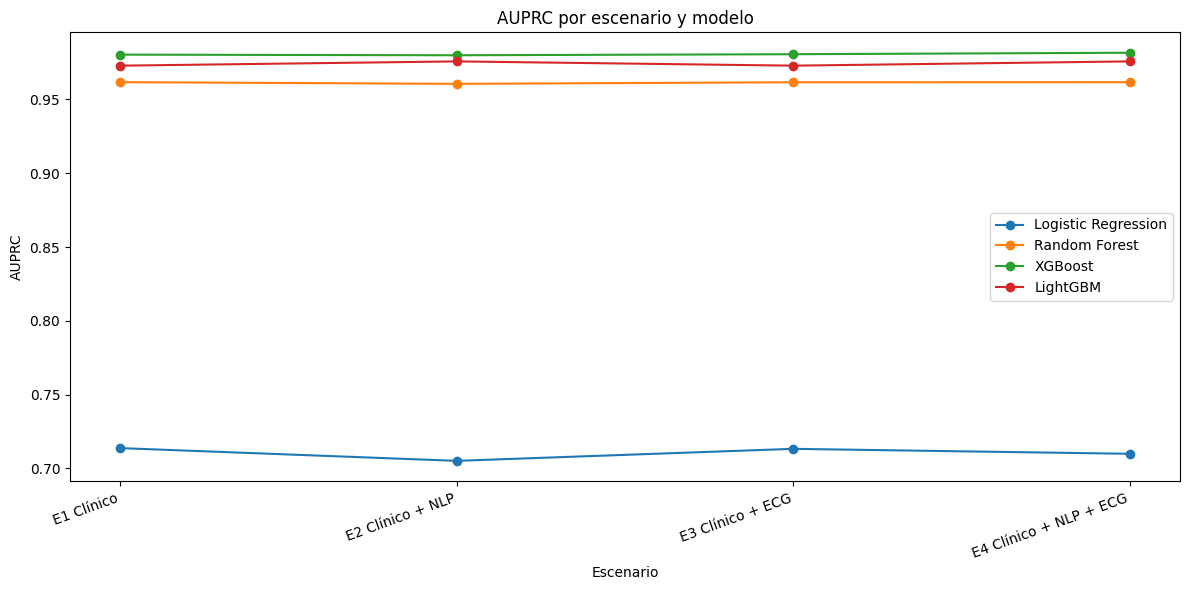

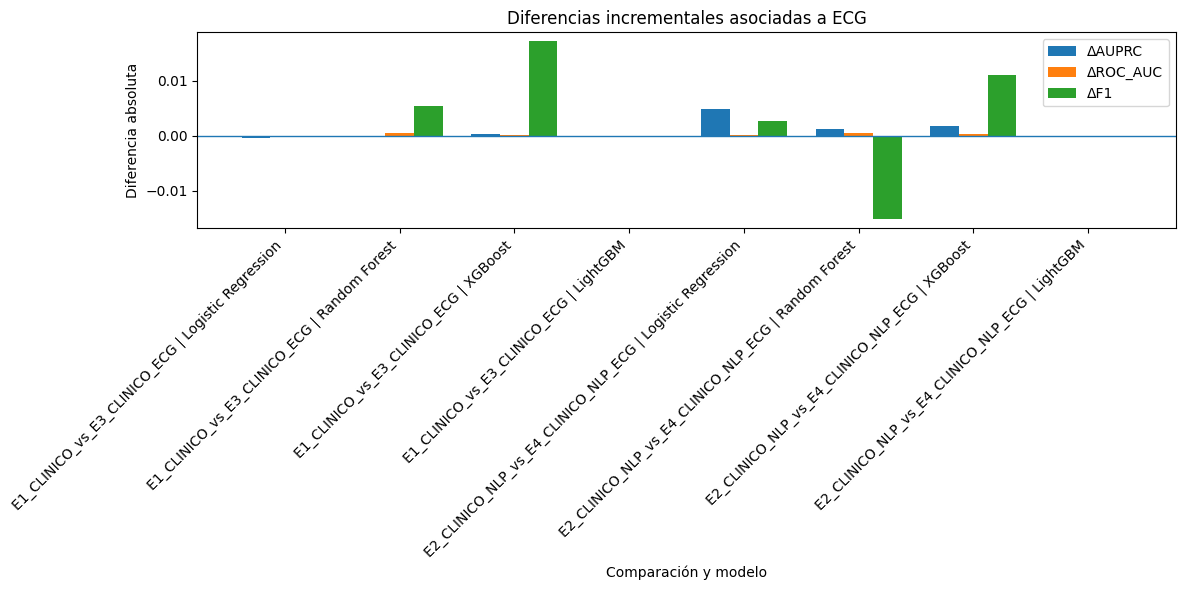

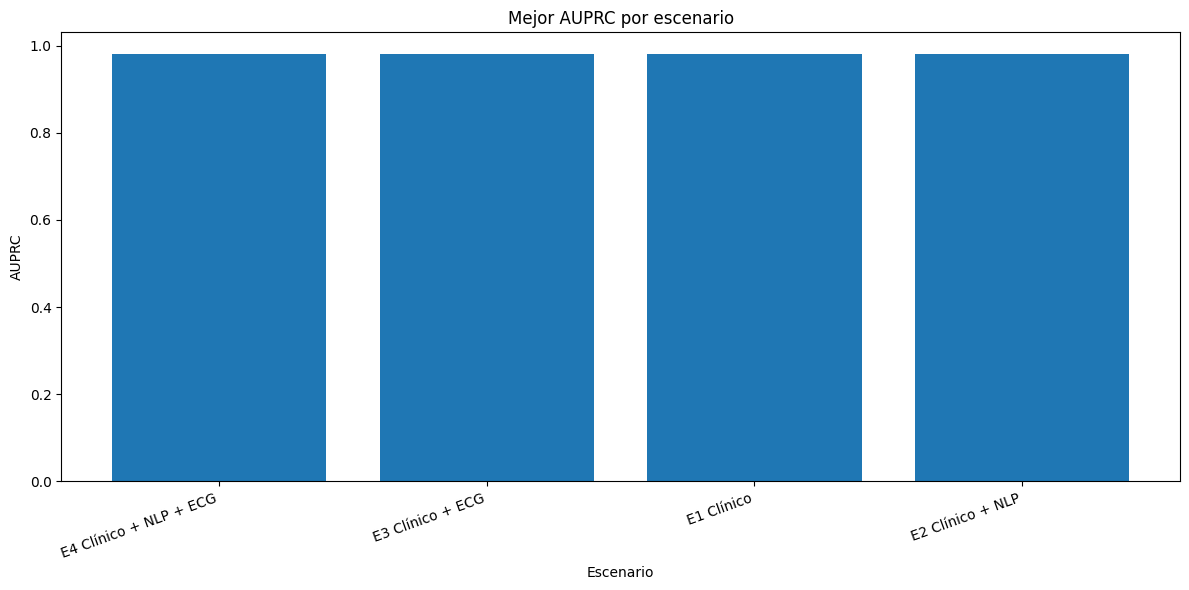

Figuras guardadas:
e:\Capacitacion 2025\Magister en Inteligencia Artificial\99 Trabajo Fin de Estudios TFE\GitHub\tfm-ecg-riesgo-cardiometabolico\notebooks\figuras_evaluacion_incremental\metricas_por_escenario_modelo.png
e:\Capacitacion 2025\Magister en Inteligencia Artificial\99 Trabajo Fin de Estudios TFE\GitHub\tfm-ecg-riesgo-cardiometabolico\notebooks\figuras_evaluacion_incremental\delta_incremental_ecg.png
e:\Capacitacion 2025\Magister en Inteligencia Artificial\99 Trabajo Fin de Estudios TFE\GitHub\tfm-ecg-riesgo-cardiometabolico\notebooks\figuras_evaluacion_incremental\ranking_auprc_por_escenario.png


In [14]:
# Figura 1: AUPRC por escenario y modelo
plt.figure(figsize=(12, 6))
plot_df = ranking.copy()
for modelo in MODELOS_ESPERADOS:
    tmp = plot_df[plot_df["modelo"].eq(modelo)]
    tmp = tmp.set_index("escenario").reindex(ESCENARIOS_ESPERADOS).reset_index()
    plt.plot(tmp["escenario"].map(scenario_label), tmp["AUPRC"], marker="o", label=modelo)
plt.title("AUPRC por escenario y modelo")
plt.xlabel("Escenario")
plt.ylabel("AUPRC")
plt.xticks(rotation=20, ha="right")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_METRICAS, dpi=150)
plt.show()

# Figura 2: delta AUPRC/ROC_AUC/F1 para comparaciones ECG
plt.figure(figsize=(12, 6))
delta_cols = ["delta_AUPRC", "delta_ROC_AUC", "delta_F1"]
delta_plot = aporte_ecg[["comparacion", "modelo"] + delta_cols].copy()
delta_plot["label"] = delta_plot["comparacion"] + " | " + delta_plot["modelo"]
x = np.arange(len(delta_plot))
width = 0.25
for i, col in enumerate(delta_cols):
    plt.bar(x + (i - 1) * width, delta_plot[col], width, label=col.replace("delta_", "Δ"))
plt.axhline(0, linewidth=1)
plt.title("Diferencias incrementales asociadas a ECG")
plt.xlabel("Comparación y modelo")
plt.ylabel("Diferencia absoluta")
plt.xticks(x, delta_plot["label"], rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DELTA_ECG, dpi=150)
plt.show()

# Figura 3: ranking AUPRC por escenario
plt.figure(figsize=(12, 6))
rank_plot = mejores_por_escenario.sort_values("AUPRC", ascending=False)
plt.bar(rank_plot["escenario"].map(scenario_label), rank_plot["AUPRC"])
plt.title("Mejor AUPRC por escenario")
plt.xlabel("Escenario")
plt.ylabel("AUPRC")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(FIG_RANKING, dpi=150)
plt.show()

print("Figuras guardadas:")
print(FIG_METRICAS)
print(FIG_DELTA_ECG)
print(FIG_RANKING)

## 12. Exportación de tablas

In [15]:
with pd.ExcelWriter(OUT_COMPARACION, engine="xlsxwriter") as writer:
    comparacion_incremental.to_excel(writer, sheet_name="COMPARACION_INCREMENTAL", index=False)
    aporte_ecg.to_excel(writer, sheet_name="APORTE_ECG", index=False)
    comparacion_por_subset.to_excel(writer, sheet_name="COMPARACION_SUBSETS", index=False)
    resumen_subsets.to_excel(writer, sheet_name="RESUMEN_SUBSETS", index=False)
    bootstrap_pareado.to_excel(writer, sheet_name="BOOTSTRAP_PAREADO", index=False)

with pd.ExcelWriter(OUT_RANKING, engine="xlsxwriter") as writer:
    ranking.to_excel(writer, sheet_name="RANKING_COMPLETO", index=False)
    mejores_por_escenario.to_excel(writer, sheet_name="MEJORES_ESCENARIO", index=False)
    mejor_global.to_excel(writer, sheet_name="MEJOR_GLOBAL", index=False)

print("Archivos exportados:")
print(OUT_COMPARACION)
print(OUT_RANKING)


Archivos exportados:
e:\Capacitacion 2025\Magister en Inteligencia Artificial\99 Trabajo Fin de Estudios TFE\GitHub\tfm-ecg-riesgo-cardiometabolico\notebooks\Comparacion_Incremental_ECG_TFM.xlsx
e:\Capacitacion 2025\Magister en Inteligencia Artificial\99 Trabajo Fin de Estudios TFE\GitHub\tfm-ecg-riesgo-cardiometabolico\notebooks\Ranking_Modelos_Escenarios_TFM.xlsx


## 13. Generación de reporte técnico

In [16]:
def fmt(x, nd=4):
    if pd.isna(x):
        return "NA"
    return f"{x:.{nd}f}"

lines = []
lines.append("RESUMEN EVALUACION INCREMENTAL ECG")
lines.append("=" * 70)
lines.append(f"Fecha generacion: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
lines.append("")
lines.append("ENTRADAS")
lines.append("-" * 70)
lines.append(f"Metricas globales: {PATH_METRICAS}")
lines.append(f"Metricas por SUBSET_BATERIA: {PATH_METRICAS_SUBSETS}")
lines.append(f"Predicciones: {PATH_PREDICCIONES if PATH_PREDICCIONES.exists() else 'No disponible'}")
lines.append(f"Variables modelado: {PATH_VARIABLES if PATH_VARIABLES.exists() else 'No disponible'}")
lines.append("")
lines.append("ESCENARIOS EVALUADOS")
lines.append("-" * 70)
for e in escenarios_presentes:
    lines.append(f"- {e}")
lines.append("")
lines.append("MODELOS EVALUADOS")
lines.append("-" * 70)
for m in modelos_presentes:
    lines.append(f"- {m}")

lines.append("")
lines.append("MEJOR MODELO POR ESCENARIO")
lines.append("-" * 70)
for _, r in mejores_por_escenario.iterrows():
    lines.append(
        f"{r['escenario']}: {r['modelo']} | AUPRC={fmt(r['AUPRC'])} | ROC_AUC={fmt(r['ROC_AUC'])} | F1={fmt(r['F1'])}"
    )

if not mejor_global.empty:
    r = mejor_global.iloc[0]
    lines.append("")
    lines.append("MEJOR CONFIGURACION GLOBAL")
    lines.append("-" * 70)
    lines.append(
        f"Escenario={r['escenario']} | Modelo={r['modelo']} | AUPRC={fmt(r['AUPRC'])} | ROC_AUC={fmt(r['ROC_AUC'])} | F1={fmt(r['F1'])}"
    )

lines.append("")
lines.append("APORTE INCREMENTAL ECG GLOBAL")
lines.append("-" * 70)
for _, r in aporte_ecg.sort_values(["comparacion", "delta_AUPRC"], ascending=[True, False]).iterrows():
    lines.append(
        f"{r['comparacion']} | {r['modelo']} | "
        f"ΔAUPRC={fmt(r['delta_AUPRC'])} | ΔROC_AUC={fmt(r['delta_ROC_AUC'])} | ΔF1={fmt(r['delta_F1'])} | "
        f"ΔRecall={fmt(r['delta_Recall'])} | ΔPrecision={fmt(r['delta_Precision'])}"
    )

lines.append("")
lines.append("SINTESIS PROMEDIO DE COMPARACIONES ECG")
lines.append("-" * 70)
for comp_name, g in aporte_ecg.groupby("comparacion"):
    lines.append(
        f"{comp_name}: "
        f"media ΔAUPRC={fmt(g['delta_AUPRC'].mean())}, "
        f"media ΔROC_AUC={fmt(g['delta_ROC_AUC'].mean())}, "
        f"media ΔF1={fmt(g['delta_F1'].mean())}"
    )

lines.append("")
lines.append("EVALUACION INCREMENTAL POR SUBCONJUNTOS ESTRUCTURALES")
lines.append("-" * 70)
lines.append(subset_msg)
lines.append(f"Filas calculadas: {len(comparacion_por_subset)}")

subset_ecg = comparacion_por_subset[comparacion_por_subset["modalidad_agregada"].eq("ECG")].copy()
if subset_ecg.empty:
    lines.append("No se encontraron comparaciones ECG por SUBSET_BATERIA.")
else:
    for (comp_name, subset_name), g in subset_ecg.groupby(["comparacion", "SUBSET_BATERIA"]):
        lines.append(
            f"{comp_name} | {subset_name}: "
            f"media ΔAUPRC={fmt(g['delta_AUPRC'].mean())}, "
            f"media ΔROC_AUC={fmt(g['delta_ROC_AUC'].mean())}, "
            f"media ΔF1={fmt(g['delta_F1'].mean())}"
        )

lines.append("")

lines.append("")
lines.append("BOOTSTRAP PAREADO XGBOOST")
lines.append("-" * 70)
for _, r in bootstrap_pareado.iterrows():
    lines.append(
        f"{r['comparacion']} | {r['metrica']} | "
        f"delta={fmt(r['delta_puntual'], 6)} | "
        f"IC95%=[{fmt(r['ic95_inferior'], 6)}, {fmt(r['ic95_superior'], 6)}] | "
        f"validas={int(r['n_bootstrap_validas'])}/{int(r['n_bootstrap_solicitadas'])}"
    )

lines.append("INTERPRETACION METODOLOGICA")
lines.append("-" * 70)
lines.append("Este notebook compara metricas obtenidas previamente y no reentrena modelos.")
lines.append("La comparacion principal para evaluar aporte ECG corresponde a E1_CLINICO vs E3_CLINICO_ECG.")
lines.append("La comparacion complementaria corresponde a E2_CLINICO_NLP vs E4_CLINICO_NLP_ECG.")
lines.append("La evaluacion estructural se calcula con Metricas_Modelado_Subsets_TFM.xlsx y SUBSET_BATERIA.")
lines.append("Los intervalos bootstrap pareados permiten distinguir diferencias puntuales de cambios compatibles con cero bajo la particion evaluada.")
lines.append("Esta evidencia no equivale a validacion clinica externa.")

OUT_REPORTE.write_text("\n".join(lines), encoding="utf-8")
print("Reporte generado:", OUT_REPORTE)
print("\n".join(lines[:45]))


Reporte generado: e:\Capacitacion 2025\Magister en Inteligencia Artificial\99 Trabajo Fin de Estudios TFE\GitHub\tfm-ecg-riesgo-cardiometabolico\notebooks\Resumen_Evaluacion_Incremental_TFM.txt
RESUMEN EVALUACION INCREMENTAL ECG
Fecha generacion: 2026-06-24 15:34:38

ENTRADAS
----------------------------------------------------------------------
Metricas globales: e:\Capacitacion 2025\Magister en Inteligencia Artificial\99 Trabajo Fin de Estudios TFE\GitHub\tfm-ecg-riesgo-cardiometabolico\notebooks\Metricas_Modelado_TFM.xlsx
Metricas por SUBSET_BATERIA: e:\Capacitacion 2025\Magister en Inteligencia Artificial\99 Trabajo Fin de Estudios TFE\GitHub\tfm-ecg-riesgo-cardiometabolico\notebooks\Metricas_Modelado_Subsets_TFM.xlsx
Predicciones: e:\Capacitacion 2025\Magister en Inteligencia Artificial\99 Trabajo Fin de Estudios TFE\GitHub\tfm-ecg-riesgo-cardiometabolico\notebooks\Predicciones_Modelos_TFM.xlsx
Variables modelado: e:\Capacitacion 2025\Magister en Inteligencia Artificial\99 Trabajo

## 14. Consideraciones metodológicas finales

La evaluación incremental se interpreta dentro del marco experimental del TFM. Una diferencia positiva entre escenarios indica mejora observada bajo los datos, modelos y particiones utilizados. Esta evidencia no equivale a validación clínica externa.

El análisis principal se centra en `E1_CLINICO → E3_CLINICO_ECG`. El análisis complementario `E2_CLINICO_NLP → E4_CLINICO_NLP_ECG` permite verificar si la modalidad ECG mantiene aporte cuando el modelo ya incorpora antecedentes procesados mediante NLP.

La evaluación por subconjuntos estructurales se calcula a partir de `Metricas_Modelado_Subsets_TFM.xlsx`. La variable `SUBSET_BATERIA` se utiliza exclusivamente como atributo de auditoría estructural y no como predictor durante el entrenamiento de modelos.
